# Sparkov Fraud Dataset — Exploratory Data Analysis

EDA tailored to the Sparkov fraud dataset and the graph-topology experiments in the paper.

Update `SPARKOV_TRAIN_PATH` and optionally `SPARKOV_TEST_PATH`.

In [4]:
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

plt.rcParams["figure.figsize"] = (9, 5)

def display_basic_overview(df, target_col=None):
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nData types:")
    display(df.dtypes.to_frame("dtype"))
    print("\nPreview:")
    display(df.head())
    if target_col and target_col in df.columns:
        print("\nTarget distribution:")
        display(df[target_col].value_counts(dropna=False).to_frame("count"))
        print("Fraud rate:", df[target_col].mean())

def missing_value_table(df):
    out = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean() * 100,
        "n_unique": df.nunique(dropna=True),
        "dtype": df.dtypes.astype(str)
    }).sort_values("missing_percent", ascending=False)
    return out

def plot_count(series, title, xlabel="", top_n=None, normalize=False):
    counts = series.value_counts(dropna=False, normalize=normalize)
    if top_n:
        counts = counts.head(top_n)
    ax = counts.plot(kind="bar")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Proportion" if normalize else "Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def plot_hist(series, title, xlabel="", bins=50, log_x=False):
    x = pd.to_numeric(series, errors="coerce").dropna()
    if log_x:
        x = np.log1p(x[x >= 0])
        xlabel = "log1p(" + xlabel + ")"
    plt.figure()
    plt.hist(x, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

def fraud_rate_by(df, col, target_col, min_count=20, top_n=20):
    tmp = (
        df.groupby(col, dropna=False)[target_col]
          .agg(["count", "sum", "mean"])
          .rename(columns={"sum": "fraud_count", "mean": "fraud_rate"})
          .sort_values(["fraud_rate", "count"], ascending=[False, False])
    )
    tmp = tmp[tmp["count"] >= min_count]
    return tmp.head(top_n)

def plot_fraud_rate_by(df, col, target_col, min_count=20, top_n=20, title=None):
    tmp = fraud_rate_by(df, col, target_col, min_count=min_count, top_n=top_n)
    if tmp.empty:
        print(f"No groups in {col} with at least {min_count} records.")
        return tmp
    ax = tmp["fraud_rate"].sort_values().plot(kind="barh")
    ax.set_title(title or f"Fraud rate by {col}")
    ax.set_xlabel("Fraud rate")
    plt.tight_layout()
    plt.show()
    display(tmp)
    return tmp

def temporal_edges_stats(df, group_col, k=1, max_group_size=None):
    if group_col not in df.columns:
        return None
    sizes = df.groupby(group_col).size()
    if max_group_size:
        sizes = sizes.clip(upper=max_group_size)
    edge_est = int(sum(max(0, int(n) - 1) * k for n in sizes))
    n_nodes = len(df)
    avg_degree_est = (2 * edge_est / n_nodes) if n_nodes else 0
    density_est = (2 * edge_est / (n_nodes * (n_nodes - 1))) if n_nodes > 1 else 0
    return {
        "relation": group_col,
        "groups": int(sizes.shape[0]),
        "median_group_size": float(sizes.median()),
        "mean_group_size": float(sizes.mean()),
        "max_group_size": int(sizes.max()),
        "estimated_undirected_edges": edge_est,
        "estimated_avg_degree": avg_degree_est,
        "estimated_density": density_est,
    }

def display_relation_diagnostics(df, relation_cols, k_map=None):
    rows = []
    for col in relation_cols:
        k = 1 if k_map is None else k_map.get(col, 1)
        stats = temporal_edges_stats(df, col, k=k)
        if stats:
            rows.append(stats)
    out = pd.DataFrame(rows)
    display(out)
    return out

In [5]:
SPARKOV_TRAIN_PATH = "/Users/royaamiri/Library/CloudStorage/OneDrive-UniversityofSunderland-LIVE/uni-lr/Credit card fraud detection/archive/fraudTrain.csv"
SPARKOV_TEST_PATH = "/Users/royaamiri/Library/CloudStorage/OneDrive-UniversityofSunderland-LIVE/uni-lr/Credit card fraud detection/archive/fraudTest.csv"

df1 = pd.read_csv(SPARKOV_TRAIN_PATH)
df2= pd.read_csv(SPARKOV_TRAIN_PATH)
df =pd.concat([df1, df2], ignore_index=True)
TARGET_COL = "is_fraud"
df[TARGET_COL] = df[TARGET_COL].astype(int)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nTarget distribution:")
print(df[TARGET_COL].value_counts())

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

df.head()

Shape: (2593350, 23)

Columns:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

Target distribution:
is_fraud
0    2578338
1      15012
Name: count, dtype: int64

Missing values:
Unnamed: 0    0
zip           0
merch_long    0
merch_lat     0
unix_time     0
trans_num     0
dob           0
job           0
city_pop      0
long          0
dtype: int64


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## 1. Data quality

In [6]:
quality = missing_value_table(df)
display(quality)
print("Duplicate rows:", df.duplicated().sum())

,missing_count,missing_percent,n_unique,dtype
Unnamed: 0,0,0.0,1296675,int64
zip,0,0.0,970,int64
merch_long,0,0.0,1275745,float64
merch_lat,0,0.0,1247805,float64
unix_time,0,0.0,1274823,int64
trans_num,0,0.0,1296675,object
dob,0,0.0,968,object
job,0,0.0,494,object
city_pop,0,0.0,879,int64
long,0,0.0,969,float64


Duplicate rows: 1296675


## 2. Class imbalance

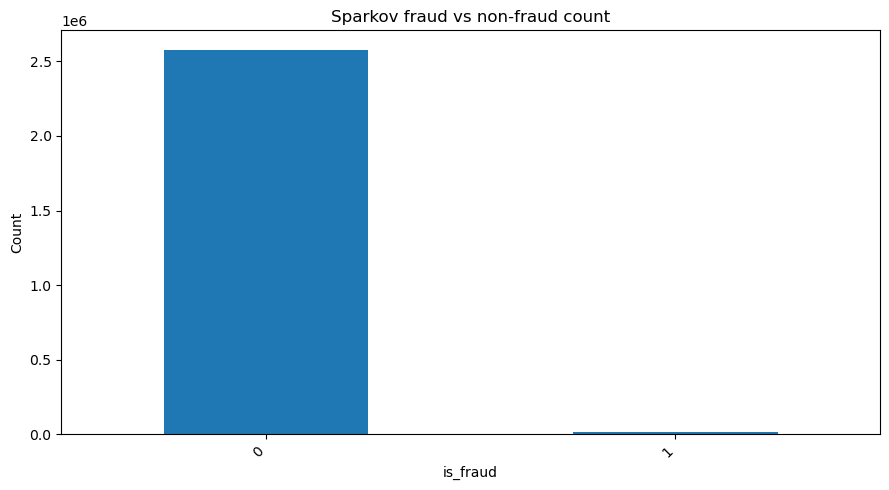

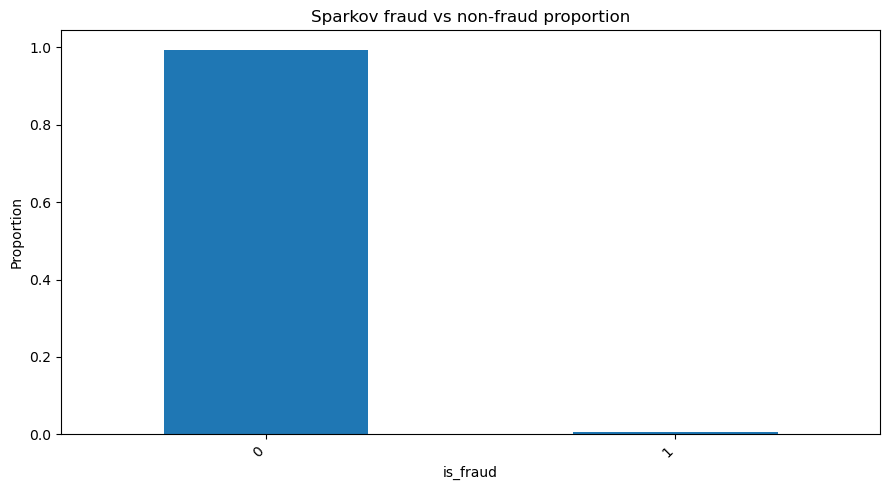

Fraud rate: 0.005789 (0.5789%)


In [7]:
plot_count(df[TARGET_COL], "Sparkov fraud vs non-fraud count", xlabel=TARGET_COL)
plot_count(df[TARGET_COL], "Sparkov fraud vs non-fraud proportion", xlabel=TARGET_COL, normalize=True)
fraud_rate = df[TARGET_COL].mean()
print(f"Fraud rate: {fraud_rate:.6f} ({fraud_rate*100:.4f}%)")

## 3. Amount analysis

,amt
count,2.593350e+06
mean,7.035104e+01
std,1.603160e+02
min,1.000000e+00
25%,9.650000e+00
50%,4.752000e+01
75%,8.314000e+01
max,2.894890e+04


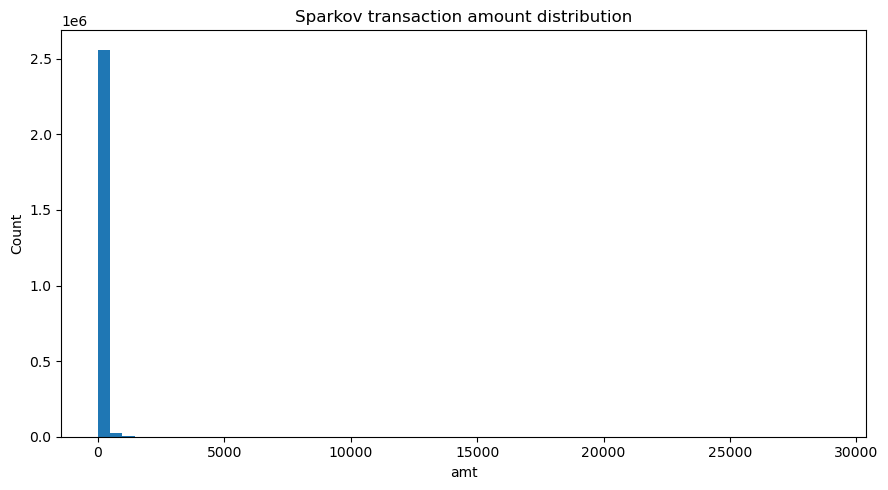

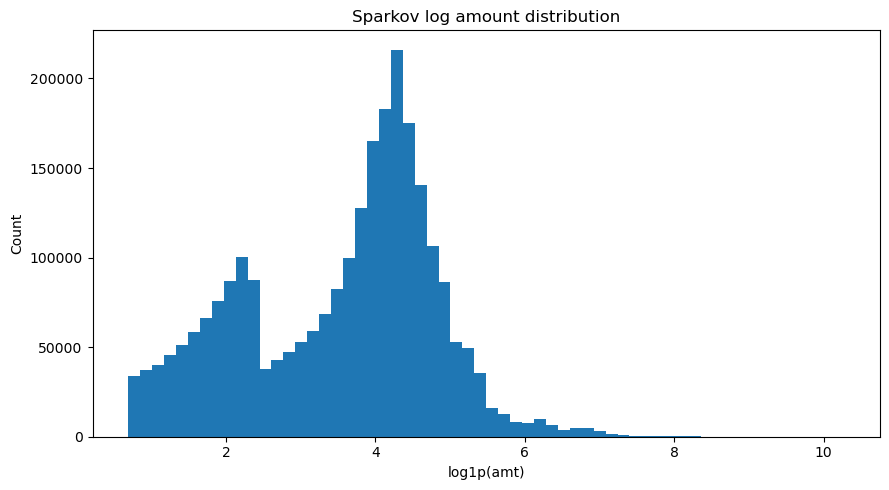

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,2578338.0,67.667110,154.007941,1.00,9.61,47.280,82.54,28948.90
1,15012.0,531.320092,390.547060,1.06,245.64,396.505,900.88,1376.04


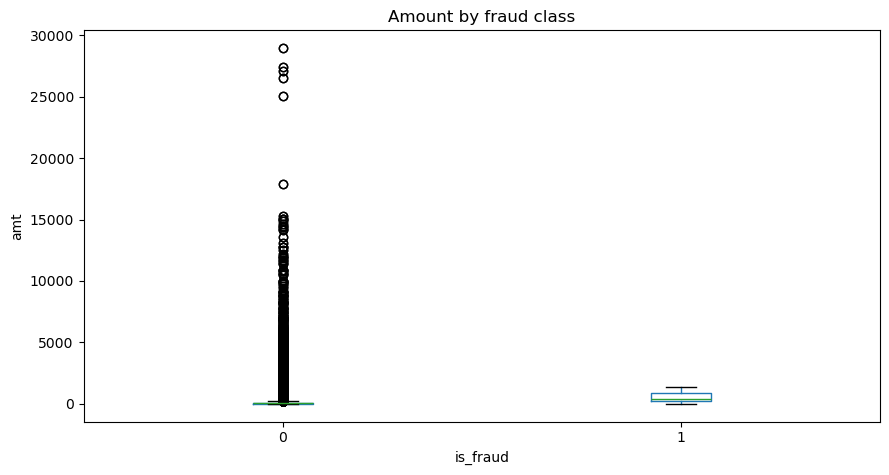

In [8]:
display(df["amt"].describe().to_frame("amt"))
plot_hist(df["amt"], "Sparkov transaction amount distribution", xlabel="amt", bins=60)
plot_hist(df["amt"], "Sparkov log amount distribution", xlabel="amt", bins=60, log_x=True)
display(df.groupby(TARGET_COL)["amt"].describe())

df.boxplot(column="amt", by=TARGET_COL, grid=False)
plt.title("Amount by fraud class")
plt.suptitle("")
plt.xlabel("is_fraud")
plt.ylabel("amt")
plt.tight_layout()
plt.show()

## 4. Temporal feature analysis

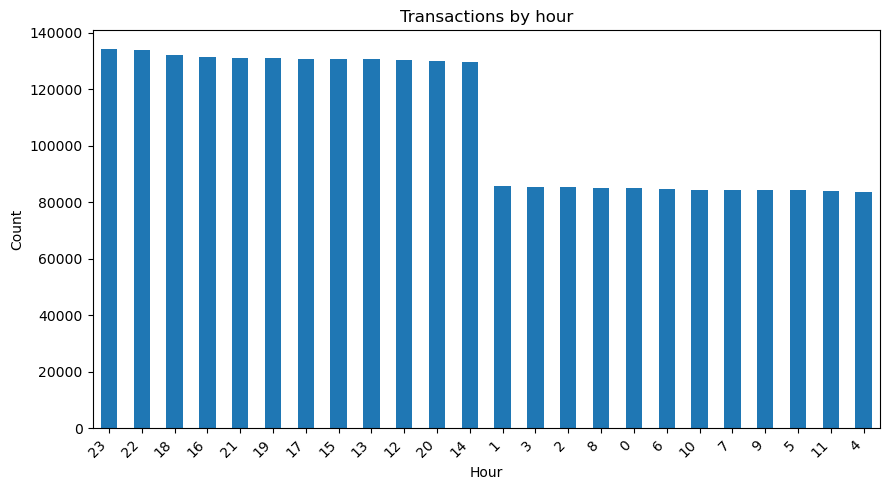

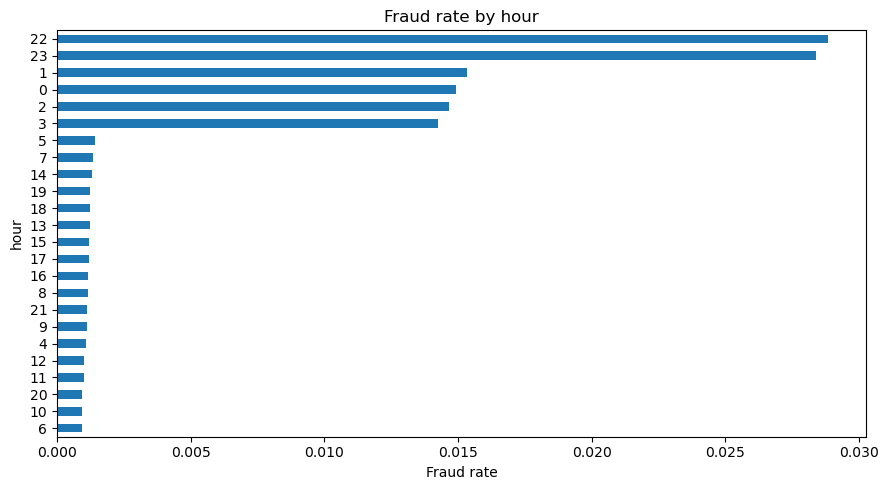

,count,fraud_count,fraud_rate
hour,,,
22,133964,3862,0.028829
23,134208,3808,0.028374
1,85738,1316,0.015349
0,85004,1270,0.014940
2,85312,1250,0.014652
3,85538,1218,0.014239
5,84342,120,0.001423
7,84406,112,0.001327
14,129770,172,0.001325


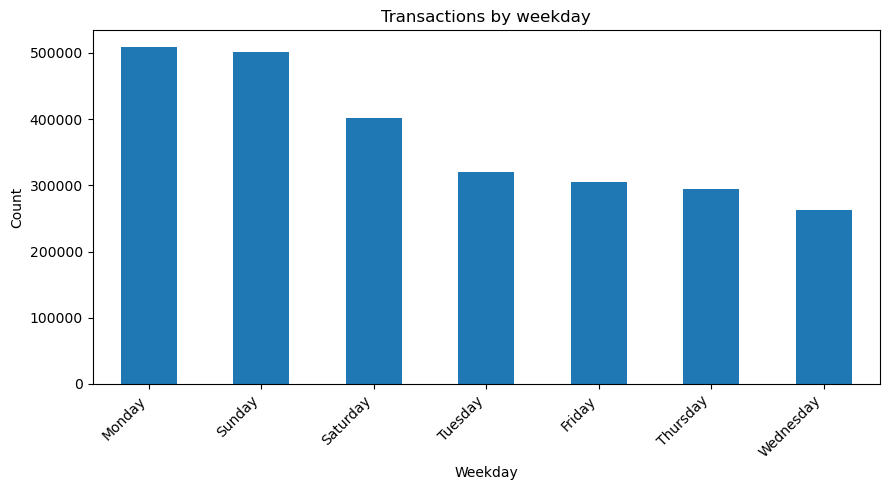

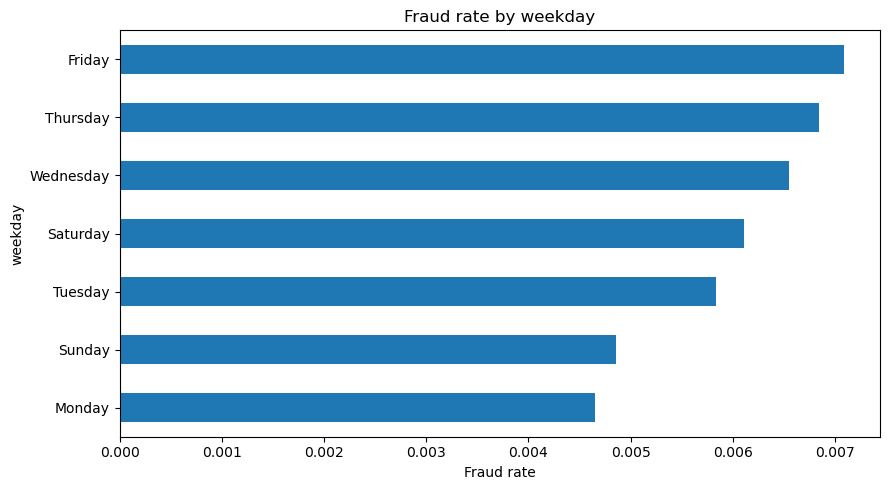

,count,fraud_count,fraud_rate
weekday,,,
Friday,304544,2158,0.007086
Thursday,294570,2016,0.006844
Wednesday,262146,1718,0.006554
Saturday,401914,2454,0.006106
Tuesday,320454,1870,0.005835
Sunday,501158,2432,0.004853
Monday,508564,2364,0.004648


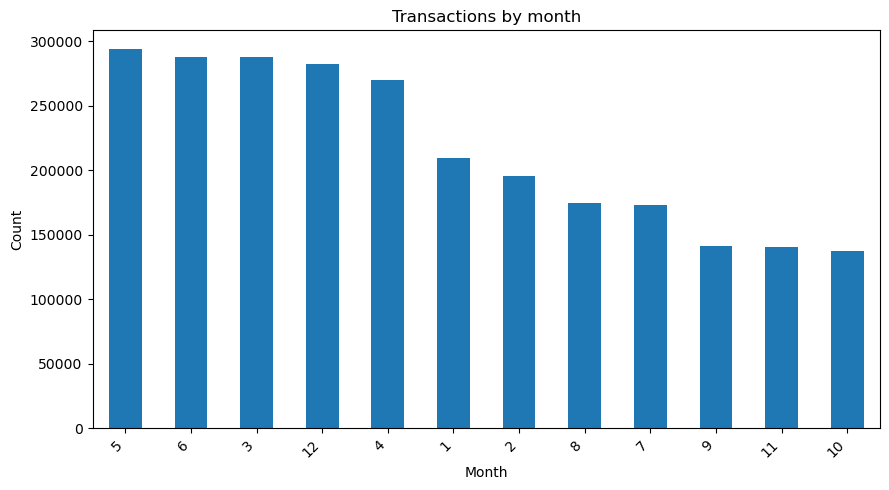

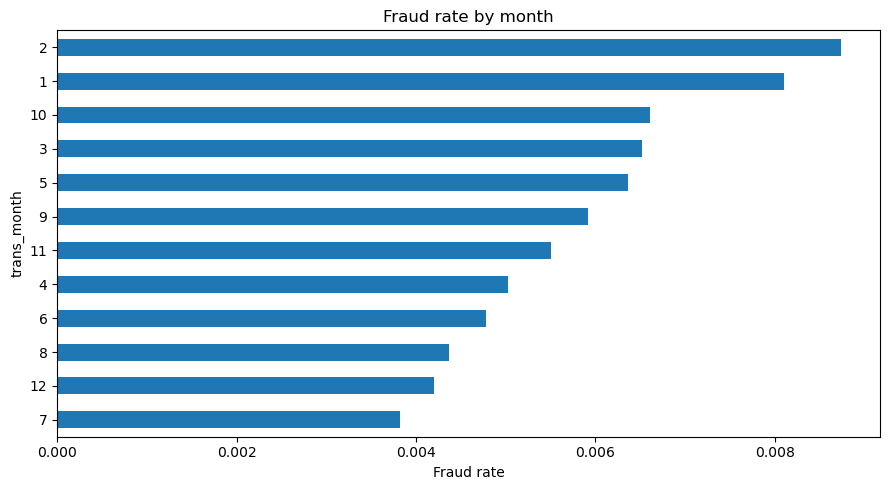

,count,fraud_count,fraud_rate
trans_month,,,
2,195314,1706,0.008735
1,209454,1698,0.008107
10,137516,908,0.006603
3,287578,1876,0.006523
5,293750,1870,0.006366
9,141304,836,0.005916
11,140842,776,0.005510
4,269940,1356,0.005023
6,287622,1376,0.004784


,count,fraud_count,fraud_rate
trans_month,,,
2,195314,1706,0.008735
1,209454,1698,0.008107
10,137516,908,0.006603
3,287578,1876,0.006523
5,293750,1870,0.006366
9,141304,836,0.005916
11,140842,776,0.005510
4,269940,1356,0.005023
6,287622,1376,0.004784


In [9]:
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"], errors="coerce")
df["hour"] = df["trans_date_trans_time"].dt.hour
df["weekday"] = df["trans_date_trans_time"].dt.day_name()
df["trans_month"] = df["trans_date_trans_time"].dt.month

plot_count(df["hour"], "Transactions by hour", xlabel="Hour")
plot_fraud_rate_by(df, "hour", TARGET_COL, min_count=20, top_n=24, title="Fraud rate by hour")

plot_count(df["weekday"], "Transactions by weekday", xlabel="Weekday")
plot_fraud_rate_by(df, "weekday", TARGET_COL, min_count=20, top_n=7, title="Fraud rate by weekday")

plot_count(df["trans_month"], "Transactions by month", xlabel="Month")
plot_fraud_rate_by(df, "trans_month", TARGET_COL, min_count=20, top_n=12, title="Fraud rate by month")

## 5. Customer and demographic analysis

,age
count,2.593350e+06
mean,4.552822e+01
std,1.740895e+01
min,1.300000e+01
25%,3.200000e+01
50%,4.400000e+01
75%,5.700000e+01
max,9.500000e+01


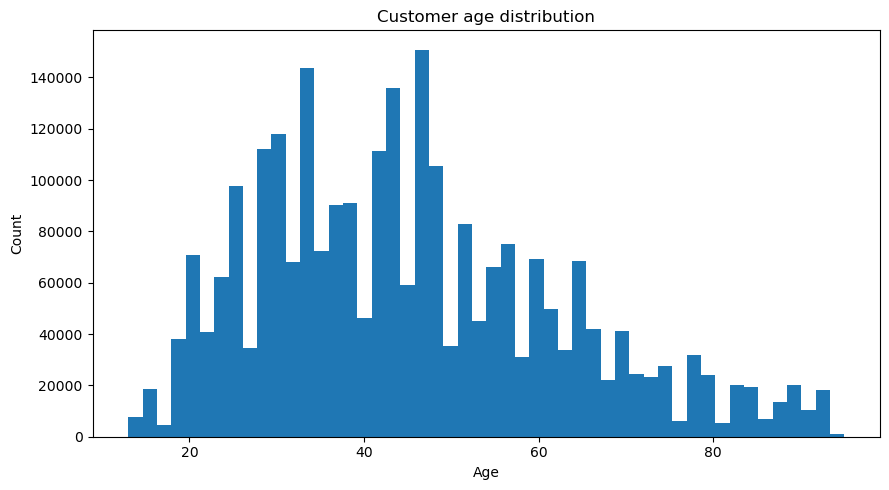

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,2578338.0,45.511960,17.398814,13.0,32.0,43.0,57.0,95.0
1,15012.0,48.321609,18.863914,14.0,33.0,47.0,60.0,93.0



--- gender ---


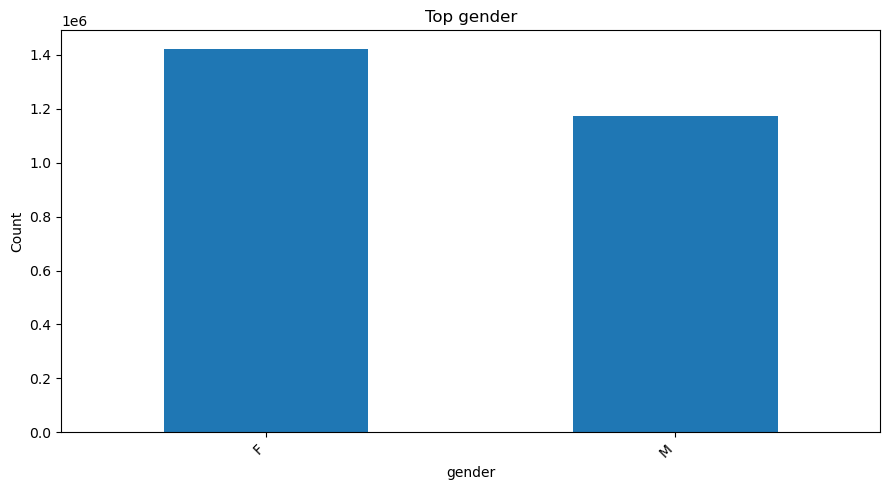

,count,fraud_count,fraud_rate
gender,,,
M,1173624,7542,0.006426
F,1419726,7470,0.005262



--- job ---


,count,fraud_count,fraud_rate
job,,,
Dancer,38,38,1.000000
Air traffic controller,34,34,1.000000
Careers adviser,30,30,1.000000
Sales promotion account executive,28,28,1.000000
"Engineer, site",24,24,1.000000
Legal secretary,24,24,1.000000
Personnel officer,24,24,1.000000
"Accountant, chartered",22,22,1.000000
Homeopath,22,22,1.000000



--- city ---


,count,fraud_count,fraud_rate
city,,,
Hubbell,38,38,1.0
Coulee Dam,30,30,1.0
Melville,30,30,1.0
Queen Anne,26,26,1.0
West Frankfort,26,26,1.0
Byesville,24,24,1.0
Clinton,24,24,1.0
Granbury,24,24,1.0
Kaktovik,24,24,1.0


...

,count,fraud_count,fraud_rate
state,,,
RI,1100,30,0.027273
AK,4240,72,0.016981
NV,11214,94,0.008382
CO,27760,226,0.008141
OR,37194,298,0.008012
TN,35108,280,0.007975
NE,48336,360,0.007448
ME,33010,238,0.007210
NH,16556,118,0.007127



--- zip ---


,count,fraud_count,fraud_rate
zip,,,
68375,38,38,1.0
11747,30,30,1.0
77038,30,30,1.0
99116,30,30,1.0
21657,26,26,1.0
62896,26,26,1.0
23117,24,24,1.0
37307,24,24,1.0
43723,24,24,1.0



--- city_pop ---


,count,fraud_count,fraud_rate
city_pop,,,
121,38,38,1.0
1439,30,30,1.0
19803,30,30,1.0
777,26,26,1.0
12626,26,26,1.0
4870,24,24,1.0
4984,24,24,1.0
9141,24,24,1.0
10085,24,24,1.0


In [10]:
if "dob" in df.columns:
    df["dob"] = pd.to_datetime(df["dob"], errors="coerce")
    df["age"] = ((df["trans_date_trans_time"] - df["dob"]).dt.days // 365)
    display(df["age"].describe().to_frame("age"))
    plot_hist(df["age"], "Customer age distribution", xlabel="Age", bins=50)
    display(df.groupby(TARGET_COL)["age"].describe())

for col in ["gender", "job", "city", "state", "zip", "city_pop"]:
    if col in df.columns:
        print(f"\n--- {col} ---")
        if df[col].nunique(dropna=True) <= 50:
            plot_count(df[col], f"Top {col}", xlabel=col, top_n=20)
        display(fraud_rate_by(df, col, TARGET_COL, min_count=20, top_n=20))

## 6. Merchant and category analysis


--- merchant ---


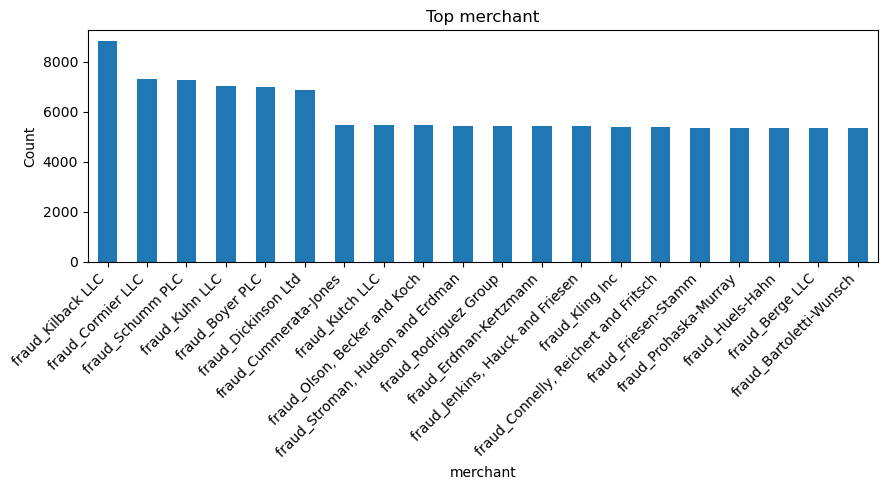

,count,fraud_count,fraud_rate
merchant,,,
fraud_Kozey-Boehm,3732,96,0.025723
"fraud_Herman, Treutel and Dickens",2600,66,0.025385
fraud_Kerluke-Abshire,3676,82,0.022307
fraud_Brown PLC,2352,52,0.022109
fraud_Goyette Inc,3886,84,0.021616
fraud_Terry-Huel,3992,86,0.021543
fraud_Jast Ltd,3906,84,0.021505
"fraud_Schmeler, Bashirian and Price",3936,82,0.020833
fraud_Boyer-Reichert,3816,76,0.019916



--- category ---


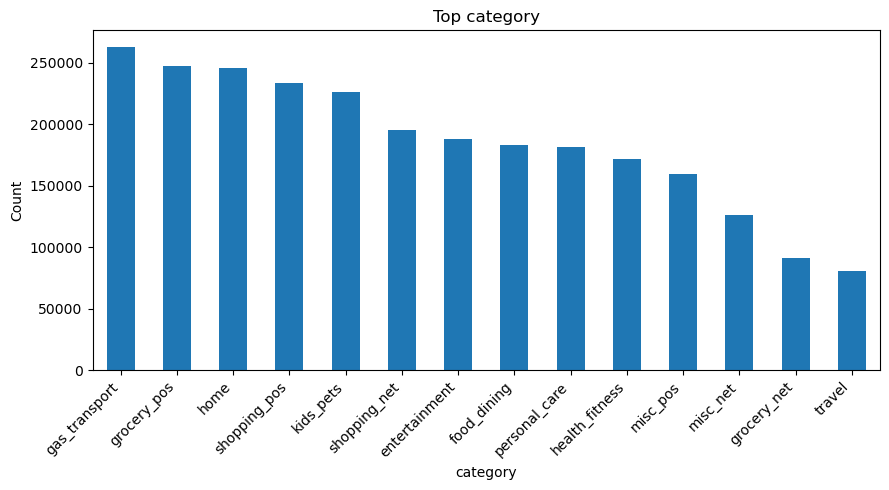

,count,fraud_count,fraud_rate
category,,,
shopping_net,195086,3426,0.017561
misc_net,126574,1830,0.014458
grocery_pos,247276,3486,0.014098
shopping_pos,233344,1686,0.007225
gas_transport,263318,1236,0.004694
misc_pos,159310,500,0.003139
grocery_net,90904,268,0.002948
travel,81014,232,0.002864
entertainment,188028,466,0.002478


In [11]:
for col in ["merchant", "category"]:
    if col in df.columns:
        print(f"\n--- {col} ---")
        plot_count(df[col], f"Top {col}", xlabel=col, top_n=20)
        display(fraud_rate_by(df, col, TARGET_COL, min_count=20, top_n=20))

## 7. Geographic and distance analysis

,distance
count,2.593350e+06
mean,7.656611e-01
std,2.847484e-01
min,2.386629e-04
25%,5.649579e-01
50%,7.983111e-01
75%,9.775360e-01
max,1.413364e+00


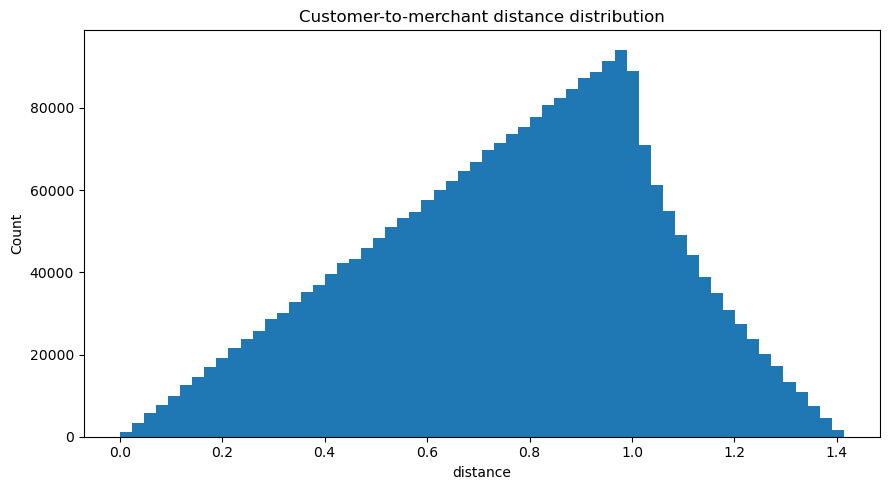

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,2578338.0,0.765652,0.284766,0.000239,0.564945,0.798321,0.977541,1.413364
1,15012.0,0.767281,0.281709,0.006658,0.567205,0.796925,0.976423,1.400695


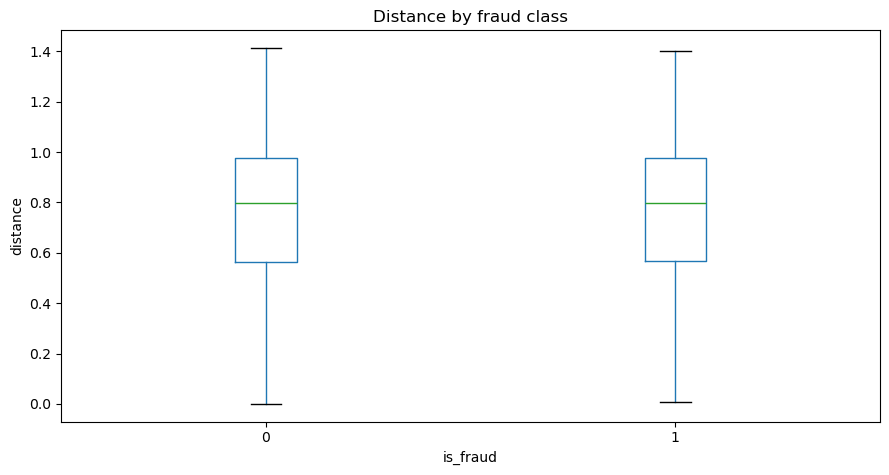

In [12]:
required_geo = ["lat", "long", "merch_lat", "merch_long"]
if all(c in df.columns for c in required_geo):
    df["distance"] = np.sqrt(
        (df["lat"] - df["merch_lat"]) ** 2 +
        (df["long"] - df["merch_long"]) ** 2
    )
    display(df["distance"].describe().to_frame("distance"))
    plot_hist(df["distance"], "Customer-to-merchant distance distribution", xlabel="distance", bins=60)
    display(df.groupby(TARGET_COL)["distance"].describe())

    df.boxplot(column="distance", by=TARGET_COL, grid=False)
    plt.title("Distance by fraud class")
    plt.suptitle("")
    plt.xlabel("is_fraud")
    plt.ylabel("distance")
    plt.tight_layout()
    plt.show()

## 8. Cardholder behaviour

,transactions_per_cc_num
count,983.00000
mean,2638.19939
std,1624.47180
min,14.00000
25%,1050.00000
50%,2108.00000
75%,4050.00000
max,6246.00000


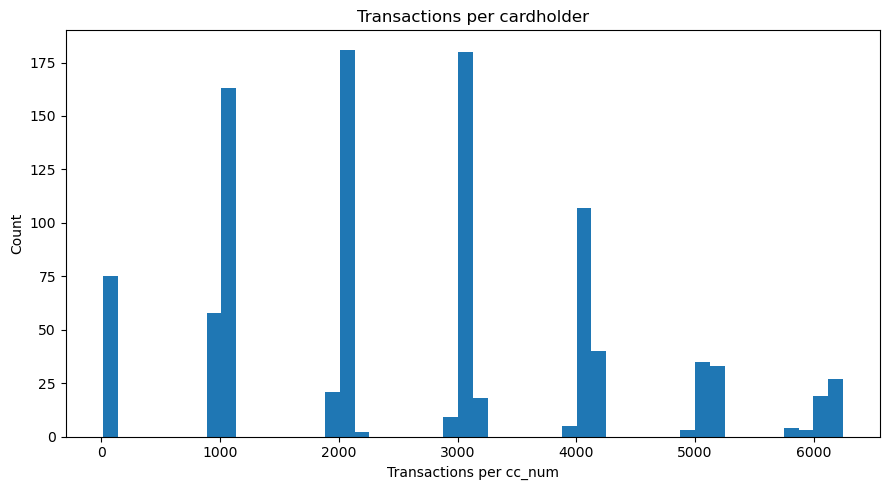

,count,fraud_count,fraud_rate
cc_num,,,
4593569795412,38,38,1.0
501851115094,30,30,1.0
3521260686633367,30,30,1.0
4168696938629925,30,30,1.0
3562793934111141,26,26,1.0
4204237326785494,26,26,1.0
577891228931,24,24,1.0
4076173495454,24,24,1.0
4629125581019,24,24,1.0


In [13]:
if "cc_num" in df.columns:
    cc_counts = df["cc_num"].value_counts()
    display(cc_counts.describe().to_frame("transactions_per_cc_num"))
    plot_hist(cc_counts, "Transactions per cardholder", xlabel="Transactions per cc_num", bins=50)
    display(fraud_rate_by(df, "cc_num", TARGET_COL, min_count=2, top_n=20))

## 9. Graph-topology diagnostics

The Sparkov pipeline uses relations such as `cc_num`, `merchant`, `category`, and `zip`.

,relation,groups,median_group_size,mean_group_size,max_group_size,estimated_undirected_edges,estimated_avg_degree,estimated_density
0,cc_num,983,2108.0,2638.199390,6246,5184734,3.998484,1.541822e-06
1,merchant,693,3726.0,3742.207792,8806,5185314,3.998931,1.541995e-06
2,category,14,185475.0,185239.285714,263318,2593336,1.999989,7.711994e-07
3,zip,970,2114.0,2673.556701,7292,2592380,1.999252,7.709151e-07



cc_num: 983 groups


,cc_num_group_size
count,983.00000
mean,2638.19939
std,1624.47180
min,14.00000
25%,1050.00000
50%,2108.00000
75%,4050.00000
max,6246.00000


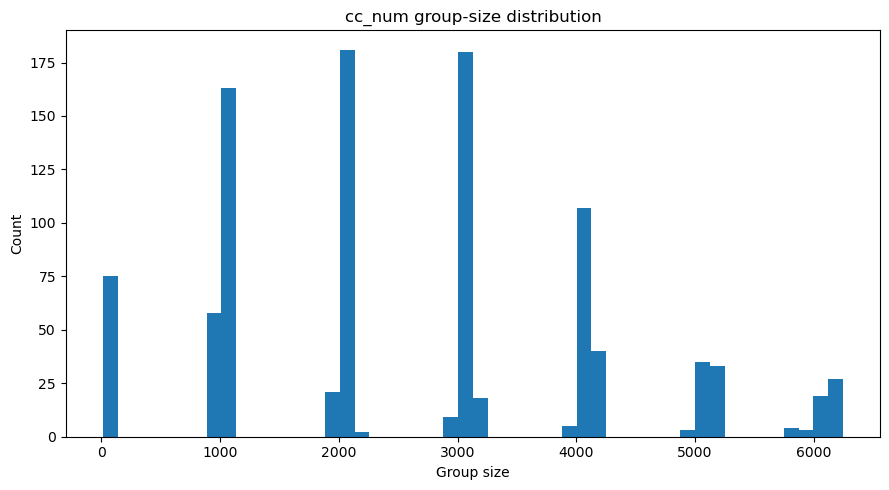


merchant: 693 groups


,merchant_group_size
count,693.000000
mean,3742.207792
std,1150.719897
min,1454.000000
25%,3184.000000
50%,3726.000000
75%,4690.000000
max,8806.000000


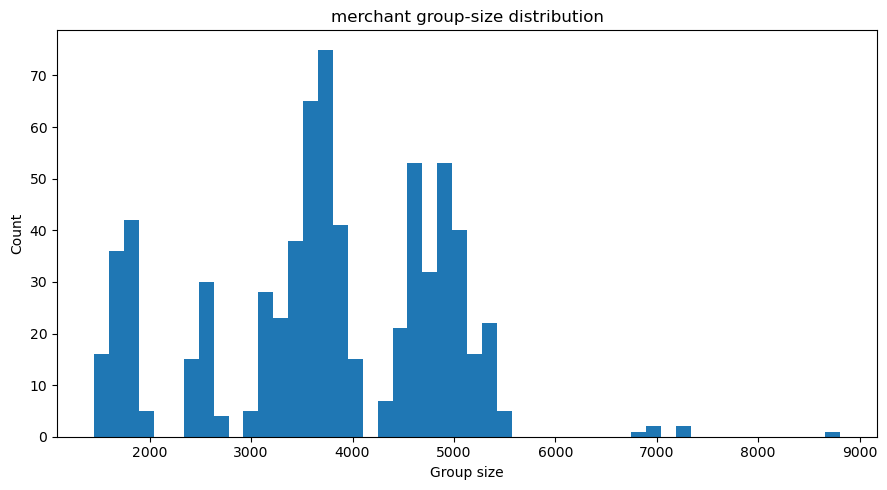


category: 14 groups


,category_group_size
count,14.000000
mean,185239.285714
std,56723.099284
min,81014.000000
25%,162422.000000
50%,185475.000000
75%,231525.500000
max,263318.000000


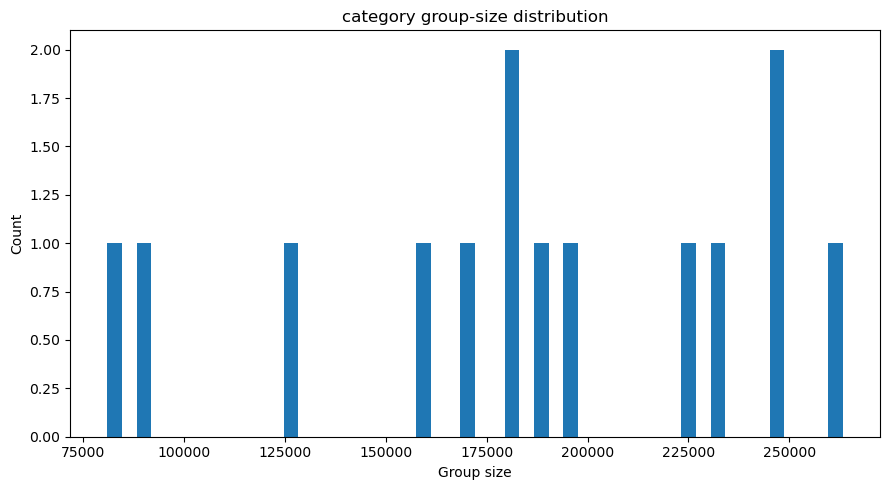


zip: 970 groups


,zip_group_size
count,970.000000
mean,2673.556701
std,1658.861153
min,14.000000
25%,1050.000000
50%,2114.000000
75%,4059.500000
max,7292.000000


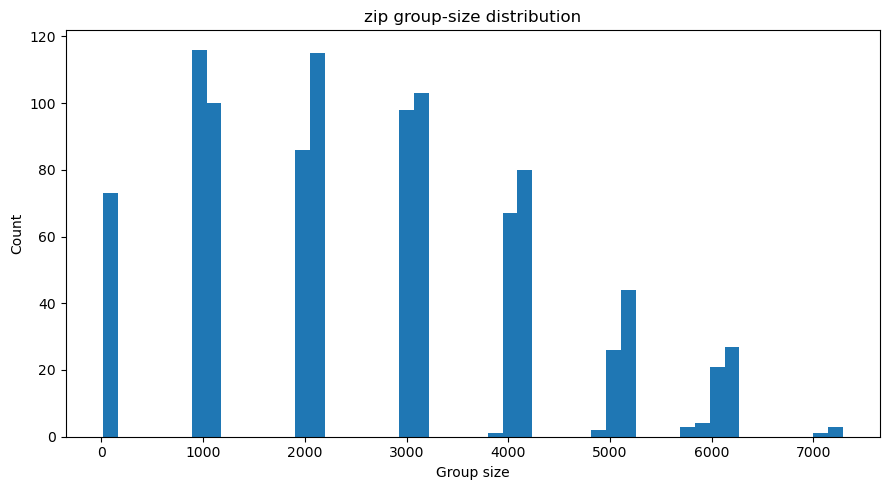

In [14]:
relation_cols = ["cc_num", "merchant", "category", "zip"]
sparkov_graph_diag = display_relation_diagnostics(df, relation_cols, k_map={
    "cc_num": 2,
    "merchant": 2,
    "category": 1,
    "zip": 1,
})

for col in relation_cols:
    if col in df.columns:
        sizes = df.groupby(col).size().sort_values(ascending=False)
        print(f"\n{col}: {sizes.shape[0]} groups")
        display(sizes.describe().to_frame(f"{col}_group_size"))
        plot_hist(sizes, f"{col} group-size distribution", xlabel="Group size", bins=50)

## 10. Key findings

Use this section after running the notebook on the full dataset.

Suggested paper-focused points:

- Sparkov often has denser cardholder histories than IBM.
- Dense `cc_num` histories can make intra-group topology competitive.
- Merchant and category relations provide cross-cardholder structure for multi-relation graphs.
- Amount, time, distance, and category patterns can explain why graph neighbours add information beyond tabular features.